# Lesson 6: Metaprompting with o1

Optimizing to production is one of the biggest painpoints we've seen developers experience with working with LLMs - with so much guidance for prompt engineering, RAG and fine-tuning out there, figuring out which optimization you need to hill-climb on your evals can be a difficult problem to frame and solve.

Luckily, it appears to be one of the use cases that `o1` is capable at. In this session we'll focus on how to use `o1-mini` to work with a set of evals to optimize our prompt for the task and improve score on our evals.


<div style="background-color:#fff6ff; padding:13px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">
<p> 💻 &nbsp; <b>Access <code>requirements.txt</code> and <code>helper.py</code> files:</b> 1) click on the <em>"File"</em> option on the top menu of the notebook and then 2) click on <em>"Open"</em>.

<p> ⬇ &nbsp; <b>Download Notebooks:</b> 1) click on the <em>"File"</em> option on the top menu of the notebook and then 2) click on <em>"Download as"</em> and select <em>"Notebook (.ipynb)"</em>.</p>

<p> 📒 &nbsp; For more help, please see the <em>"Appendix – Tips, Help, and Download"</em> Lesson.</p>

</div>

<p style="background-color:#f7fff8; padding:15px; border-width:3px; border-color:#e0f0e0; border-style:solid; border-radius:6px"> 🚨
&nbsp; <b>Different Run Results:</b> The output generated by AI models can vary with each execution due to their dynamic, probabilistic nature. Don't be surprised if your results differ from those shown in the video.</p>

In [1]:
# Warning control
import warnings
warnings.filterwarnings('ignore')

# Import OpenAI key
from helper import get_openai_api_key
openai_api_key = get_openai_api_key()

In [2]:
from openai import OpenAI
from IPython.display import display, Markdown
import pandas as pd
from concurrent.futures import ThreadPoolExecutor
from functionDefinitions import TOOLS
import csv
import json
import os
import matplotlib.pyplot as plt

GPT_MODEL = 'gpt-4o-mini'
O1_MODEL = 'o1'

client = OpenAI(api_key=openai_api_key)

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)


In [3]:
from redlines import Redlines
from IPython.display import display, Markdown

def compare_strings(string1, string2):
    # Create a Redlines object to compare the strings
    diff = Redlines(string1, string2)
    
    # Display the differences using Markdown
    display(Markdown(diff.output_markdown))

# Example usage
string_a = "This is the original text for comparison purposes."
string_b = "This is the modified text to compare for differences."

compare_strings(string_a, string_b)

This is the <span style='color:red;font-weight:700;text-decoration:line-through;'>original </span><span style='color:green;font-weight:700;'>modified </span>text <span style='color:green;font-weight:700;'>to compare </span>for <span style='color:red;font-weight:700;text-decoration:line-through;'>comparison purposes.</span><span style='color:green;font-weight:700;'>differences.</span>

## Step 1: Generate 4o routine (prompt)

We'll take the Flight Cancellation Policy that we have created and convert it to an LLM-based routine with the following prompt.

This process is also a good use of O1, using a purely text document to create instructions and tools for an LLM to make use of. To dive deeper on this topic check out [this cookbook](https://cookbook.openai.com/examples/o1/using_reasoning_for_routine_generation).

In [4]:
with open('originalPolicy/flightCancellationsPolicy.md', 'r') as file:
    flight_cancellation_policy = file.read()
    print(flight_cancellation_policy)

# **Internal Flight Cancellations and Changes Policy**

**Purpose**: This document serves as a detailed guide for internal support agents to handle flight cancellations and changes. The focus is on providing clear instructions, ensuring efficiency, consistency, and customer satisfaction during calls.

**Note**: Always maintain a calm, empathetic tone while assisting customers, especially during stressful situations involving cancellations or major changes.

## **Table of Contents**

1. General Guidelines for Handling Customer Requests  
2. Cancellations: Types and Policies  
3. Changes: Types and Policies  
4. Rebooking Guidelines  
5. Compensation and Refund Rules  
6. Special Cases  
7. FAQs for Common Scenarios

### **1\. General Guidelines for Handling Customer Requests**

* **Confirm Identity**: Verify the customer's identity by asking for their booking reference and any additional required details (e.g., name and flight number).  
* **Listen and Understand**: Clarify if the custo

In [5]:
CONVERSION_PROMPT = f"""
You are a helpful assistant tasked with taking an external facing help center article and converting it into a internal-facing programmatically executable routine optimized for an LLM. 
The LLM using this routine will be tasked with reading the policy, answering incoming questions from customers, and helping drive the case toward resolution.

Please follow these instructions:
1. **Review the customer service policy carefully** to ensure every step is accounted for. It is crucial not to skip any steps or policies.
2. **Organize the instructions into a logical, step-by-step order**, using the specified format. 
3. **Use the following format**:
   - **Main actions are numbered** (e.g., 1, 2, 3).
   - **Sub-actions are lettered** under their relevant main actions (e.g., 1a, 1b).
      **Sub-actions should start on new lines**
   - **Specify conditions using clear 'if...then...else' statements** (e.g., 'If the product was purchased within 30 days, then...').
   - **For instructions that require more information from the customer**, provide polite and professional prompts to ask for additional information.
   - **For actions that require data from external systems**, write a step to call a function using backticks for the function name (e.g., call the `check_delivery_date` function).
      - **If a step requires the customer service agent to take an action** (e.g., process a refund), generate a function call for this action (e.g., call the `process_refund` function).
      - **Only use the available set of functions that are defined below.
   - **If there is an action an assistant can perform on behalf of the user**, include a function call for this action (e.g., call the `change_email_address` function), and ensure the function is defined with its purpose and required parameters.
      - **Only use the available set of functions that are defined below.
   - **The step prior to case resolution should always be to ask if there is anything more you can assist with**.
   - **End with a final action for case resolution**: calling the `case_resolution` function should always be the final step.
4. **Ensure compliance** by making sure all steps adhere to company policies, privacy regulations, and legal requirements.
5. **Handle exceptions or escalations** by specifying steps for scenarios that fall outside the standard policy.
6. **Ensure coverage** by checking that all of the conditions covered in the policy are also covered in the routines

**Important**: Always wrap the functions you return in backticks i.e. `check_ticket_type`. Do not include the arguments to the functions.

Here are the currently available set of functions in JSON format: 
TOOLS: {TOOLS}

Please convert the following customer service policy into the formatted routine, ensuring it is easy to follow and execute programmatically. Ensure that you **only** use the functions provided and do **not** create net new functions."""

In [6]:
def generate_routine(policy):
    try:
        messages = [
            {
                "role": "user",
                "content": f"""
                    {CONVERSION_PROMPT}

                    POLICY:
                    {policy}
                """
            }
        ]

        response = client.chat.completions.create(
            model='o1-mini',
            messages=messages
        )
        

        return response.choices[0].message.content 
    except Exception as e:
        print(f"An error occurred: {e}")

In [7]:
flight_cancellation_routine = generate_routine(flight_cancellation_policy)

In [8]:
display(Markdown(flight_cancellation_routine))

1. **Confirm Identity**
   - a. Prompt the customer: "Could you please provide your booking reference, full name, and flight number to verify your identity?"
   - b. Call the `verify_identity` function.

2. **Listen and Understand Customer Request**
   - a. Prompt the customer: "Are you looking to cancel your flight, make a change to your booking, or inquire about compensation?"
   - b. If the customer wants to **cancel**, proceed to step 3.
   - c. If the customer wants to **change** their booking, proceed to step 4.
   - d. If the customer wants to **inquire about compensation**, proceed to step 5.
   - e. Else, call the `ask_clarification` function with the prompt: "Could you please clarify your request?"

3. **Handle Cancellations**
   - a. Call the `check_ticket_type` function with the booking reference.
   - b. If the ticket is **refundable**, then:
      - i. If within 24 hours of booking, call the `process_full_refund` function.
      - ii. Else, call the `check_fare_rules` function.
          - If eligible for partial refund, call the `process_partial_refund` function with the refund amount.
   - c. If the ticket is **non-refundable**, then:
      - i. Offer flight credit by calling the `offer_flight_credit` function.
      - ii. Inform the customer about any applicable penalty fees by prompting: "There is a penalty fee applicable for non-refundable tickets."
   - d. If the cancellation is **airline-initiated** due to weather-related issues, then:
      - i. Call the `rebook_without_fee` function.
      - ii. If the customer does not accept rebooking, call the `process_full_refund` function.
   - e. If the cancellation is **airline-initiated** due to mechanical issues or operational changes, then:
      - i. Call the `prioritize_missed_connections` function.
      - ii. If an overnight stay is required, call the `offer_accommodation` function.
   - f. If the customer is a **no-show**:
      - i. If the ticket is non-refundable, inform the customer: "No refunds are issued for no-shows, but travel credits may be available."
      - ii. If the ticket is refundable, call the `process_partial_refund` function for applicable taxes or fees.
   - g. Proceed to step 7.

4. **Handle Changes**
   - a. Call the `check_ticket_type` function with the booking reference.
   - b. Prompt the customer: "Would you like to make a same-day change or a change in advance?"
   - c. If **same-day change**:
      - i. If the ticket is **flexible**, call the `process_change_no_fee` function.
      - ii. If the ticket is **non-flexible**, call the `apply_change_fee` function and prompt the customer: "A change fee applies, and any fare differences will need to be paid."
   - d. If **change in advance**:
      - i. Prompt the customer for the desired change date.
      - ii. If the change is **within 7 days of departure**, call the `apply_change_fee` function.
      - iii. If the change is **beyond 7 days**, then:
          - 1. If the ticket allows, call the `apply_lesser_change_fee` function.
          - 2. Else, proceed with standard change fees.
   - e. If the change is **airline-initiated** due to schedule changes, then:
      - i. If **minor changes** (less than 2 hours), inform the customer of the new schedule and offer alternative only upon request.
      - ii. If **major changes** (2+ hours), prompt the customer: "Would you like to rebook, receive a full refund, or take travel credit?" 
          - Based on the response, call `rebook_without_fee`, `process_full_refund`, or `offer_flight_credit` respectively.
   - f. Proceed to step 7.

5. **Handle Compensation Inquiries**
   - a. Call the `check_compensation_eligibility` function with the booking reference.
   - b. If eligible for compensation under **EU/US rules**, then:
      - i. Inform the customer of their rights based on delay length and cause.
      - ii. If delay exceeds four hours, offer meal vouchers or hotel accommodation by calling `offer_accommodation`.
   - c. Proceed to step 7.

6. **Handle Special Cases**
   - a. If the customer cites a **medical emergency**:
      - i. Prompt for a medical certificate.
      - ii. Call the `process_flexible_cancellation` function with the booking reference and medical certificate.
      - iii. For flight changes due to illness, call the `waive_change_fees` function with necessary documentation.
   - b. If the customer is dealing with **bereavement**:
      - i. Prompt for bereavement documentation.
      - ii. Call the `apply_bereavement_flexibility` function with the booking reference and documentation.
   - c. If the booking is a **group booking**:
      - i. If individual cancellation is requested, call the `process_partial_group_cancellation` function.
      - ii. If a name change is requested, ensure it is within the allowed limits and call the `permit_name_change` function.
   - d. If the booking involves an **unaccompanied minor**:
      - i. Call the `arrange_supervision` function if flight changes are needed.
      - ii. Prioritize rebooking by calling the `prioritize_minors_rebooking` function.
   - e. Proceed to step 7.

7. **Rebooking Guidelines**
   - a. Call the `check_next_available_flight` function with the booking reference.
   - b. If no suitable flights are available, call the `check_interline_partners` function.
      - i. If an interline partner flight is available, call the `book_interline_flight` function.
   - c. If the customer requests an upgrade, call the `offer_available_upgrades` function.
   - d. If the preferred flight is fully booked, offer the next available option and place the customer on a waitlist if possible.
      - i. Optionally, offer an upgrade by calling the `offer_available_upgrades` function.
   - e. Proceed to step 7.

8. **Final Assistance and Case Resolution**
   - a. Prompt the customer: "Is there anything else I can assist you with today?"
   - b. If yes, return to step 2.
   - c. If no, call the `case_resolution` function with the booking reference and resolution details.

9. **Exception Handling and Escalations**
   - a. If the customer's request falls outside standard policies, prompt: "I understand your concern. Let me escalate this to a supervisor for further assistance."
   - b. Proceed to call the appropriate escalation function as defined internally (not covered by available functions).

### Data quality check

We'll check that `o1-mini` has followed our instructions and used only the functions we provided.

If it added additional ones, we'll need to write functions for them before proceeding.

In [9]:
import re
from collections import Counter

def compare_lists(a, b):
    # Create Counters for both lists
    counter_a = Counter(a)
    counter_b = Counter(b)
    
    # Find elements that are only in A or have a higher count in A
    diff_a = counter_a - counter_b
    # Find elements that are only in B or have a higher count in B
    diff_b = counter_b - counter_a
    
    # Report differences
    print("Items in A that are not in B (or more of in A):")
    for item, count in diff_a.items():
        print(f"{item}: {count}")

    print("\nItems in B that are not in A (or more of in B):")
    for item, count in diff_b.items():
        print(f"{item}: {count}")

def extract_function_names(text):
    # Use regex to match text between backticks and extract function names
    pattern = r'`(.*?)`'
    matches = re.findall(pattern, text)
    return matches

# Extract a unique list of the functions in the generated routine
function_names_from_o1 = set(extract_function_names(flight_cancellation_routine))

# Extract the list of TOOLs we provided the model
function_names_defined = [tool["function"]["name"] for tool in TOOLS if tool["type"] == "function"]

# Print the differences
## Items that are in A and not in B need functions written for them
## Items that are in B and not in A are fine, they are just unused in the routine the model has written
compare_lists(function_names_from_o1, function_names_defined)

Items in A that are not in B (or more of in A):

Items in B that are not in A (or more of in B):
provide_alternative_options: 1
book_flight: 1
determine_refund_method: 1
process_refund: 1
apply_travel_credit: 1
process_destination_change: 1
assist_third_party_booking: 1
assess_compensation_request: 1


## Step 2: Evaluation

Now that we have a routine generated with o1, we can run it against our evaluation suite and measure its accuracy.

We'll start by creating an agent that is equipped with the policy and a list of tools. It will be given messages from an existing conversation and will be tasked with determining the next best action to take

In [10]:
def agent_response(transcript, policy, model):
    try:
        messages = [
            {
                "role": "system",
                "content": f"""
You are a customer service agent that is responsible for handling airline related issues. Below is the exact policy that you must follow to address the customer's issue.

POLICY:
{policy}
                """
            }
        ]

        messages.extend(transcript)
        response = client.chat.completions.create(
            model=model,
            messages=messages,
            tools=TOOLS,
            parallel_tool_calls=False,
        temperature=0)
        
        return response.choices[0].message 
    except Exception as e:
        print(f"An error occurred: {e}")
        print(messages)

We will process each row in parallel to reduce runtime and compare the function call + inputs that the model selects against our expected function + parameters.

In [11]:
import math 

def safe_str(value):
    return "" if (isinstance(value, float) and math.isnan(value)) else str(value)

def process_row(row_number,test_row,policy,model,iteration=0, verbose=False):
    # Extract variables from test_row
    context = test_row['context']
    request = test_row['request']
    full_name = test_row['full_name']
    booking_ref = test_row['booking_ref']
    flight_no = test_row['flight_no']
    ticket_type = test_row['ticket_type']
    fare_rules = safe_str(test_row['fare_rules'])
    medical_certificate = safe_str(test_row['medical_certificate'])
    refund_amount = safe_str(test_row['refund_amount'])
    expected_function = test_row['expected_function']
    expected_inputs_str = test_row['expected_inputs']
    expected_inputs = json.loads(expected_inputs_str)

    CUSTOMER_PROMPT = f"""<objective>You are a customer named {full_name} trying to resolve an issue with a customer service agent.
    Continue providing the information the agent requests so they can solve your issue.
    If you have the information in your *details* then use that. Otherwise, generate an appropriate answer.</objective>
    <details>
    Booking Reference: {booking_ref}
    Flight Number: {flight_no}
    {f"Medical Reference: {medical_certificate}" if medical_certificate else ""}
    Context: {context}
    Your initial request: {request}
    </details>
    <guidance>
    Remember that YOU are the customer.
    If the agent needs some information, that must come from you. 
    Do not ask the agent for information.
    </guidance>
    """

    # Initialize transcript
    transcript = [{"role": "user", "content": request}]
    if verbose:
        print(f'Starting request: {request}')
    
    # Initialize variables
    is_correct = False

    loop_count = 0
    while True:
        loop_count += 1
        if loop_count > 10:
            actual_function = None
            actual_inputs = None
            break
        # Call agent_response with the current transcript, policy, model
        response = agent_response(transcript, policy, GPT_MODEL)
        
        # Extract assistant message content and tool_calls
        if response:
            assistant_message_content = response.content
            tool_calls = response.tool_calls
        else:
            assistant_message_content = None
            tool_calls = None
        
        if not tool_calls:
            # Append assistant's message to transcript
            transcript.append({"role": "assistant", "content": assistant_message_content})
            
            # Get customer response
            customer_messages = [{"role": "system", "content": CUSTOMER_PROMPT}]
            customer_messages.extend(transcript)
            
            customer_response = client.chat.completions.create(model=GPT_MODEL, messages=customer_messages)
            
            # Append customer response to transcript
            transcript.append({"role": "user", "content": customer_response.choices[0].message.content})
            
            # Continue the loop
            continue
        else:
            #print(tool_calls)
            # There is a tool call
            tool_call = tool_calls[0]  # Assuming we're only interested in the first tool call
            function_name = tool_call.function.name
            arguments = json.loads(tool_call.function.arguments)
            
            if function_name == 'verify_identity':
                # Append assistant's message to transcript
                transcript.append(response)
                
                # Simulate the tool response
                tool_response = "True"
                
                # Append the tool response to transcript
                transcript.append({"role": "tool", "content": tool_response, "tool_call_id": tool_call.id})
                
                # Continue the loop
                continue
            elif function_name == 'ask_clarification':
                # Take the 'prompt' from arguments and use it as assistant message
                clarification_prompt = arguments.get('prompt')
                
                # Append assistant's clarification message
                transcript.append({"role": "assistant", "content": clarification_prompt})
                
                # Get customer response
                customer_messages = [{"role": "system", "content": CUSTOMER_PROMPT}]
                customer_messages.extend(transcript)
                
                customer_response = client.chat.completions.create(model=GPT_MODEL, messages=customer_messages)
                
                # Append customer response to transcript
                transcript.append({"role": "user", "content": customer_response.choices[0].message.content})
                
                # Continue the loop
                continue
            elif function_name == 'check_ticket_type':
                # Append assistant's message to transcript
                transcript.append(response)
                
                tool_response = f'Ticket type: {ticket_type}\nFare rules: {fare_rules}'
                
                # Append the tool response to transcript
                transcript.append({"role": "tool", "content": tool_response, "tool_call_id": tool_call.id})
                
                # Continue the loop
                continue
            elif function_name == 'check_fare_rules':
                # Append assistant's message to transcript
                transcript.append(response)
                
                tool_response = f'Ticket type: {ticket_type}\nFare rules: {fare_rules}'

                if fare_rules == 'partial_refund':
                    tool_response += f'\nRefund amount: {refund_amount}'
                
                # Append the tool response to transcript
                transcript.append({"role": "tool", "content": tool_response, "tool_call_id": tool_call.id})
                
                # Continue the loop
                continue
            elif function_name == 'get_refund_amount':
                # Append assistant's message to transcript
                transcript.append(response)
                
                tool_response = f'Refund amount: {refund_amount}'
                
                # Append the tool response to transcript
                transcript.append({"role": "tool", "content": tool_response, "tool_call_id": tool_call.id})
                
                # Continue the loop
                continue
            elif function_name == 'check_next_available_flight':
                # Append assistant's message to transcript
                transcript.append(response)
                
                # simulating the tool response
                tool_response = f'Next available flight: LMG091 at 10:00 AM Tomorrow'
                
                # Append the tool response to transcript
                transcript.append({"role": "tool", "content": tool_response, "tool_call_id": tool_call.id})
                
                # Continue the loop
                continue
            elif function_name == 'provide_alternative_options':
                # Append assistant's message to transcript
                transcript.append(response)
                
                # simulating the tool response
                tool_response = f'Next available flight: FR9876 at 5:00 PM Tomorrow'
                
                # Append the tool response to transcript
                transcript.append({"role": "tool", "content": tool_response, "tool_call_id": tool_call.id})
                
                # Continue the loop
                continue
            else:
                if verbose:
                    print('Got a successful function call')
                # Stop and compare function call and arguments with expected_function and expected_inputs
                transcript.append(response)
                actual_function = function_name
                actual_inputs = arguments
                is_correct = (actual_function == expected_function) and (str(actual_inputs) == str(expected_inputs))
                
                # Break the loop
                break
    
    # Return the results
    return {
        'request': request,
        'context': context,
        'expected_function': expected_function,
        'expected_inputs': expected_inputs,
        'actual_function': actual_function,
        'actual_inputs': actual_inputs,
        'is_correct': is_correct,
        'transcript': transcript
    }

# added post-filming to address transcript size
def filter_messages(message_list):
    messages = []
    for item in message_list:
        # Convert the item to a string and check if 'ChatCompletionMessage' is in it.
        if 'ChatCompletionMessage' in str(item):
            #print(item)
            message = {"role": "assistant",
                       "tool_call": {
                           "name": item.tool_calls[0].function.name,
                           "arguments": item.tool_calls[0].function.arguments
                       }
                      }
            messages.append(message)
        else:
            messages.append(item)
    return messages


def evaluate_function_calls(df, policy, model, i=0, verbose=False):
    records = []

    # Use ThreadPoolExecutor to process rows in parallel
    with ThreadPoolExecutor() as executor:
        futures = {executor.submit(process_row, row_number, row, policy, model, i, verbose): row_number for row_number, row in df.iterrows()}
        for future in futures:
            record = future.result()
            records.append(record)


    df = pd.DataFrame(records)
    df['cleaned_transcript'] = df['transcript'].apply(filter_messages)
    total_accuracy = df['is_correct'].mean()
    return df, total_accuracy

Let's take a look at the results

In [12]:
eval_df = pd.read_csv('evals/policyEvals.csv')
eval_df.head()

,ID,context,request,full_name,booking_ref,flight_no,expected_function,expected_inputs,ticket_type,fare_rules,medical_certificate,refund_amount
0,0,I want to cancel my flight as I am initiating the cancellation myself.,"I would like to cancel my flight, please.",John Doe,ABC123,XYZ789,process_partial_refund,"{""booking_reference"":""ABC123"",""refund_amount"":198}",refundable,partial_refund,NaN,198.0
1,1,I want to change my flight to a different date.,I'd like to initiate a change to my flight for a later date.,Jane Smith,DEF456,XYZ123,apply_change_fee,"{""booking_reference"":""DEF456""}",nonrefundable,NaN,NaN,NaN
2,2,I want to request a refund because my flight was canceled by the airline due to weather.,"My flight was canceled by the airline, and I want a refund.",Emma Johnson,GHI789,ABC123,process_full_refund,"{""booking_reference"":""GHI789""}",refundable,full_refund,NaN,NaN
3,3,I want to cancel my flight but I think it is non-refundable.,I want to cancel my non-refundable ticket.,Michael Brown,JKL012,DEF456,offer_flight_credit,"{""booking_reference"":""JKL012""}",nonrefundable,NaN,NaN,NaN
4,4,I want to cancel my flight and I believe it is refundable.,I want to cancel my refundable ticket.,Sarah Brown,MNO345,STU678,process_partial_refund,"{""booking_reference"":""MNO345"",""refund_amount"":65}",refundable,partial_refund,NaN,65.0


In [13]:
from termcolor import colored

def display_row(index):
    eval_row = eval_df.iloc[index]
    df_row = df.iloc[index][["actual_function", "actual_inputs", "is_correct", "cleaned_transcript"]]
    transcript_list = df_row["cleaned_transcript"]

    print("Eval DataFrame Row:")
    print(eval_row)
    print("\nDataFrame Columns:")
    print("actual_function:", df_row["actual_function"])
    print("actual_inputs:", df_row["actual_inputs"])
    print("is_correct:", df_row["is_correct"])
    print("transcript:")
    for entry in transcript_list:
        role = entry["role"] if isinstance(entry, dict) else getattr(entry, "role", None)
        color = "blue" if role == "user" else "red"
        print(colored(str(entry), color))


In [14]:
df, accuracy = evaluate_function_calls(eval_df, flight_cancellation_routine, GPT_MODEL)

# Display the accuracy as a mini header
display(Markdown(f"### Accuracy: {accuracy:.2%}"))

display(df)

### Accuracy: 70.59%

,request,context,expected_function,expected_inputs,actual_function,actual_inputs,is_correct,transcript,cleaned_transcript
0,"I would like to cancel my flight, please.",I want to cancel my flight as I am initiating the cancellation myself.,process_partial_refund,"{'booking_reference': 'ABC123', 'refund_amount': 198}",process_full_refund,{'booking_reference': 'ABC123'},False,"[{'role': 'user', 'content': 'I would like to cancel my flight, please.'}, {'role': 'assistant', 'content': 'Could you please provide your booking reference, full name, and flight number to verify your identity?'}, {'role': 'user', 'content': 'My booking reference is ABC123, my flight number is XYZ789, and my name is John Doe.'}, ChatCompletionMessage(content=None, refusal=None, role='assistant', audio=None, function_call=None, tool_calls=[ChatCompletionMessageToolCall(id='call_B75GGaOCLZYHMH3iYxEWSoL8', function=Function(arguments='{""booking_reference"":""ABC123"",""full_name"":""John Doe"",""flight_number"":""XYZ789""}', name='verify_identity'), type='function')], annotations=[]), {'role': 'tool', 'content': 'True', 'tool_call_id': 'call_B75GGaOCLZYHMH3iYxEWSoL8'}, {'role': 'assistant', 'content': 'Thank you for verifying your identity, John Doe. Are you looking to cancel your flight?'}, {'role': 'user', 'content': 'Yes, I would like to proceed with the cancellation of my flight.'}, ChatCompletionMessage(content=None, refusal=None, role='assistant', audio=None, function_call=None, tool_calls=[ChatCompletionMessageToolCall(id='call_lHxu0KUdUkkNEtAdioYzMNjl', function=Function(arguments='{""booking_reference"":""ABC123""}', name='check_ticket_type'), type='function')], annotations=[]), {'role': 'tool', 'content': 'Ticket type: refundable Fare rules: partial_refund', 'tool_call_id': 'call_lHxu0KUdUkkNEtAdioYzMNjl'}, ChatCompletionMessage(content='Your ticket is refundable. Since you are within 24 hours of booking, I will proceed to process a full refund for you. ', refusal=None, role='assistant', audio=None, function_call=None, tool_calls=[ChatCompletionMessageToolCall(id='call_Ou0KcyMYB1upCqqPjrzikqFT', function=Function(arguments='{""booking_reference"":""ABC123""}', name='process_full_refund'), type='function')], annotations=[])]","[{'role': 'user', 'content': 'I would like to cancel my flight, please.'}, {'role': 'assistant', 'content': 'Could you please provide your booking reference, full name, and flight number to verify your identity?'}, {'role': 'user', 'content': 'My booking reference is ABC123, my flight number is XYZ789, and my name is John Doe.'}, {'role': 'assistant', 'tool_call': {'name': 'verify_identity', 'arguments': '{""booking_reference"":""ABC123"",""full_name"":""John Doe"",""flight_number"":""XYZ789""}'}}, {'role': 'tool', 'content': 'True', 'tool_call_id': 'call_B75GGaOCLZYHMH3iYxEWSoL8'}, {'role': 'assistant', 'content': 'Thank you for verifying your identity, John Doe. Are you looking to cancel your flight?'}, {'role': 'user', 'content': 'Yes, I would like to proceed with the cancellation of my flight.'}, {'role': 'assistant', 'tool_call': {'name': 'check_ticket_type', 'arguments': '{""booking_reference"":""ABC123""}'}}, {'role': 'tool', 'content': 'Ticket type: refundable Fare rules: partial_refund', 'tool_call_id': 'call_lHxu0KUdUkkNEtAdioYzMNjl'}, {'role': 'assistant', 'tool_call': {'name': 'process_full_refund', 'arguments': '{""booking_reference"":""ABC123""}'}}]"
1,I'd like to initiate a change to my flight for a later date.,I want to change my flight to a different date.,apply_change_fee,{'booking_reference': 'DEF456'},apply_change_fee,{'booking_reference': 'DEF456'},True,"[{'role': 'user', 'content': 'I'd like to initiate a change to my flight for a later date.'}, {'role': 'assistant', 'content': 'Could you please provide your booking reference, full name, and flight number to verify your identity?'}, {'role': 'user', 'content': 'Sure! My booking reference is DEF456, my full name is Jane Smith, and my flight number is XYZ12

In [15]:
display_row(8)

Eval DataFrame Row:
ID                                                                                 8
context                       I want to cancel my flight due to a medical emergency.
request                   I want to cancel my flight because of a medical emergency.
full_name                                                                Laura Adams
booking_ref                                                                   YZA567
flight_no                                                                     PQR678
expected_function                                      process_flexible_cancellation
expected_inputs        {"booking_reference":"YZA567","medical_certificate":"MC1234"}
ticket_type                                                                 flexible
fare_rules                                                                       NaN
medical_certificate                                                           MC1234
refund_amount                                

## Step 3: Improve 4o routine

Let's now leverage o1 again to add in a metaprompting loop to see if we can improve the quality of our evals.

We'll take the following multi-step approach:
- We'll pass in the current routine + eval results to o1 and ask it analyze the results and update the routine accordingly
- Since o1 does not currently support structured outputs, we'll chain with output with a 4o to enforce a schema we can parse
- Finally, we take the new routine and run it back through our eval to generate new results

We'll run this loop a fixed number of times and see what improvements we can make

In [16]:
def get_openai_response(messages, model, response_format=None):
    try:
        if response_format:
            response = client.chat.completions.create(
                model=model,
                messages=messages,
                response_format={"type": "json_schema", "json_schema": response_format}
            )
        else:
            response = client.chat.completions.create(
                model=model,
                messages=messages
            )
        return response.choices[0].message.content
    except Exception as e:
        print(f"An error occurred: {e}")


OUTPUT_SCHEMA = {
                    "name": "policy_output",
                    "schema": {
                    "type": "object",
                    "properties": {
                        "final_answer": { "type": "string" }
                    },
                    "required": ["final_answer"],
                    "additionalProperties": False
                    },
                    "strict": True
                }

In [17]:
start_o1_message = [
    {
        "role": "user",
        "content": f"""# Instructions
You are an agent that is responsible for improving the quality of instructions that are provided to a customer service LLM agent. 
Your task is to improve the instructions that are provided to the LLM agent in order to increase accuracy on a test set while adhering to the initial policy. 

## Criteria
- Analyze the existing instructions and the results of the eval. Understand which behaviors lead to failures.
- For example, if the LLM agent is not asking for the booking reference when it is needed, you should add a step to ask for the booking reference.
- Improve the instructions to address the gaps in the eval results.
- Ensure changes made are compliant with the original policy.
- Only use the tools provided.
- Use the functions provided to the best of your ability to ensure the LLM agent can handle the customer service requests effectively. Including gathering data where necessary.
- Try changing the format if this formatting doesn't work well - consider basic XML (e.g. <step> <substep> <if> <case>) or markdown as alternatives.

You will be provided with 4 items:
1) The ground-truth policy for the customer service agent containing detailed instructions on how to handle flight cancellations and changes.
2) Full list of available functions.
3) A routine instruction set.
4) A results that shows the LLMs performance on a test set using this routine instruction set. This dataset contains columns showing:
    - request: This is the initial user request. 
    - expected_function: This is the function we expect the LLM to call at the end of the conversation. 
    - expected_input: This is the input we expect the LLM to provide to the function at the end of the conversation.
    - actual_function: This is the final function the LLM called using the current instructions.
    - actual_input: These are the function parameters the LLM provided based on the current instructions.
    - transcript: This is the conversation transcript between the user and the LLM agent. 
    - is_correct: True/False value depending on if the model responded correctly

You may be provided with a history of edits and evaluations. You can use this information to understand what has been tried before and what has worked or not worked.

# Data

## 1. Original policy
{flight_cancellation_policy}

## 2. Functions
{TOOLS}

# Conclusion

Return the improved policy exactly as written within the defined JSON. Remove all parts from the LLM's answer that are not part of the policy, and do not create additional keys.
"""
     }
]

In [18]:
import tiktoken 

encoding = tiktoken.get_encoding("o200k_base")

def num_tokens_from_messages(messages):
    entire_input = ""
    for message in messages:
        entire_input += message["content"] + " "
    tokens = encoding.encode(entire_input)
    return len(tokens)

When improving the routine, consider these approaches:
- Adding synthetic examples to show the model how to choose between two commonly mistaken functions
- Given it general guidance on what attributes to look out for which it commonly mislabels
- Being more specific with your guidance on how to follow the routine.

<p style="background-color:#f7fff8; padding:15px; border-width:3px; border-color:#e0f0e0; border-style:solid; border-radius:6px"> 🚨
&nbsp; <b>High Token Warning!:</b> Running the following cell consumes many tokens. Running multiple times may result in a message regarding exceeding a monthy quota.</p>

In [19]:
# start with data from first run
routines = [flight_cancellation_routine]
results = [df]
accuracies = [round(accuracy * 100, 2)]
o1_messages = start_o1_message.copy()

MAX_TOKENS = 120000

for i in range(3):
    display(Markdown(f"## Iteration {i+1}"))
    
    # Build a candidate message with the most recent eval (full table)
    prev_results = results[-1]
    pf = prev_results.drop(columns=['transcript'])

    new_eval_content = (
        f"## 3. Routine instructions:\n"
        f"{routines[-1]}\n"
        f"## 4. Results table:\n"
        f"{pf.to_json(orient='records')}\n"
    )
    
    # Check token count before adding the newest eval
    candidate_messages = o1_messages + [{"role": "user", "content": new_eval_content}]
    if num_tokens_from_messages(candidate_messages) <= MAX_TOKENS:
        o1_messages.append({"role":"user", "content": new_eval_content})
    else:
        # If we can't even fit the newest eval, consider truncation or error handling
        # For simplicity, we skip truncation logic here
        print("excluding eval content {num_tokens_from_messages(candidate_messages)}")
        pass

    print(f"num tokens {num_tokens_from_messages(o1_messages)}")
    print(f"len messages {len(o1_messages)}")


    # Get the updated routine from the metaprompting assistant
    temp_routine_json = get_openai_response(o1_messages
                                            , O1_MODEL
                                            ,response_format=OUTPUT_SCHEMA)
    #temp_routine_str = temp_routine_json.strip("json```").strip("```")
    new_routine = json.loads(temp_routine_json)["final_answer"]
    routines.append(new_routine)

    eval_df = pd.read_csv('evals/policyEvals.csv')

    # Evaluate the function calls with the current policy on the gpt-4o model
    eval_df, accuracy = evaluate_function_calls(
        eval_df,
        new_routine,
        GPT_MODEL,
        i
    )
    accuracies.append(round(accuracy * 100, 2))
    results.append(eval_df)
    display(Markdown(f"### Accuracy: {accuracy:.2%}"))

    #list the IDs of the failed rows
    failed_ids = eval_df[eval_df['is_correct'] == False].index.tolist()
    display(eval_df.loc[failed_ids])
    eval_df.to_csv(f'evals/results_run_{i+1}.csv', index=False)

    # Instantiate fresh o1 message
    o1_messages = start_o1_message.copy()

    # Attempt to include older examples (omitting 'transcript') within token limit
    older_results = results[:-1][::-1]  # all except the newest, reversed for most recent first
    for old_eval_df in older_results:
        if 'transcript' in old_eval_df.columns:
            truncated_df = old_eval_df.drop(columns=['transcript','cleaned_transcript'])
        else:
            truncated_df = old_eval_df

        old_content = "## Older eval (no transcript):\n" + truncated_df.to_json(orient='records')
        candidate_messages = o1_messages + [{"role": "user", "content": old_content}]
        if num_tokens_from_messages(candidate_messages) <= MAX_TOKENS:
            o1_messages.append({"role": "user", "content": old_content})
        else:
            # If we exceed token limits, stop adding older examples
            break


## Iteration 1

num tokens 13124
len messages 2


### Accuracy: 70.59%

,request,context,expected_function,expected_inputs,actual_function,actual_inputs,is_correct,transcript,cleaned_transcript
0,"I would like to cancel my flight, please.",I want to cancel my flight as I am initiating the cancellation myself.,process_partial_refund,"{'booking_reference': 'ABC123', 'refund_amount': 198}",process_partial_refund,"{'booking_reference': 'ABC123', 'refund_amount': 100}",False,"[{'role': 'user', 'content': 'I would like to cancel my flight, please.'}, {'role': 'assistant', 'content': 'Could you please provide your booking reference, full name, and flight number to verify your identity?'}, {'role': 'user', 'content': 'My booking reference is ABC123, my flight number is XYZ789, and my name is John Doe.'}, ChatCompletionMessage(content=None, refusal=None, role='assistant', audio=None, function_call=None, tool_calls=[ChatCompletionMessageToolCall(id='call_6ibudMvZ2F81TauWGnOGox2E', function=Function(arguments='{""booking_reference"":""ABC123"",""full_name"":""John Doe"",""flight_number"":""XYZ789""}', name='verify_identity'), type='function')], annotations=[]), {'role': 'tool', 'content': 'True', 'tool_call_id': 'call_6ibudMvZ2F81TauWGnOGox2E'}, {'role': 'assistant', 'content': 'Thank you for verifying your identity. Are you looking to cancel your flight?'}, {'role': 'user', 'content': 'Yes, I would like to proceed with canceling my flight.'}, ChatCompletionMessage(content=None, refusal=None, role='assistant', audio=None, function_call=None, tool_calls=[ChatCompletionMessageToolCall(id='call_cGpWu2FBnEfsXo2W4rIGA4R1', function=Function(arguments='{""booking_reference"":""ABC123""}', name='check_ticket_type'), type='function')], annotations=[]), {'role': 'tool', 'content': 'Ticket type: refundable Fare rules: partial_refund', 'tool_call_id': 'call_cGpWu2FBnEfsXo2W4rIGA4R1'}, ChatCompletionMessage(content='Your ticket is refundable, but it falls under partial refund fare rules. I will now process the partial refund for you. Please hold on for a moment.', refusal=None, role='assistant', audio=None, function_call=None, tool_calls=[ChatCompletionMessageToolCall(id='call_VCiFE6CJg4FaBHFWgy0TT3D8', function=Function(arguments='{""booking_reference"":""ABC123"",""refund_amount"":100}', name='process_partial_refund'), type='function')], annotations=[])]","[{'role': 'user', 'content': 'I would like to cancel my flight, please.'}, {'role': 'assistant', 'content': 'Could you please provide your booking reference, full name, and flight number to verify your identity?'}, {'role': 'user', 'content': 'My booking reference is ABC123, my flight number is XYZ789, and my name is John Doe.'}, {'role': 'assistant', 'tool_call': {'name': 'verify_identity', 'arguments': '{""booking_reference"":""ABC123"",""full_name"":""John Doe"",""flight_number"":""XYZ789""}'}}, {'role': 'tool', 'content': 'True', 'tool_call_id': 'call_6ibudMvZ2F81TauWGnOGox2E'}, {'role': 'assistant', 'content': 'Thank you for verifying your identity. Are you looking to cancel your flight?'}, {'role': 'user', 'content': 'Yes, I would like to proceed with canceling my flight.'}, {'role': 'assistant', 'tool_call': {'name': 'check_ticket_type', 'arguments': '{""booking_reference"":""ABC123""}'}}, {'role': 'tool', 'content': 'Ticket type: refundable Fare rules: partial_refund', 'tool_call_id': 'call_cGpWu2FBnEfsXo2W4rIGA4R1'}, {'role': 'assistant', 'tool_call': {'name': 'process_partial_refund', 'arguments': '{""booking_reference"":""ABC123"",""refund_amount"":100}'}}]"
5,I missed my connecting flight because of the airline delay.,I want to address the issue of missing my connecting flight due to a delay caused by the airline.,prioritize_missed_connections,{'booking_reference': 'PQR678'},check_compensation_eligibility,{'booking_reference': 'PQR678'},False,"[{'role': 'user', 'content': 'I missed my connecting flight because of the airline delay.'}, {'role': 'assistant', 'content': 'Could you please provide your booking reference, full name, and flight number to verify

## Iteration 2

...

,request,context,expected_function,expected_inputs,actual_function,actual_inputs,is_correct,transcript,cleaned_transcript
0,"I would like to cancel my flight, please.",I want to cancel my flight as I am initiating the cancellation myself.,process_partial_refund,"{'booking_reference': 'ABC123', 'refund_amount': 198}",process_partial_refund,"{'booking_reference': 'ABC123', 'refund_amount': 198.0}",False,"[{'role': 'user', 'content': 'I would like to cancel my flight, please.'}, {'role': 'assistant', 'content': 'Could you please provide your booking reference, full name, and flight number to verify your identity?'}, {'role': 'user', 'content': 'My booking reference is ABC123, my flight number is XYZ789, and my name is John Doe.'}, ChatCompletionMessage(content=None, refusal=None, role='assistant', audio=None, function_call=None, tool_calls=[ChatCompletionMessageToolCall(id='call_ug9wsuV7z5dKeYxb0CcYLGN3', function=Function(arguments='{""booking_reference"":""ABC123"",""full_name"":""John Doe"",""flight_number"":""XYZ789""}', name='verify_identity'), type='function')], annotations=[]), {'role': 'tool', 'content': 'True', 'tool_call_id': 'call_ug9wsuV7z5dKeYxb0CcYLGN3'}, ChatCompletionMessage(content=None, refusal=None, role='assistant', audio=None, function_call=None, tool_calls=[ChatCompletionMessageToolCall(id='call_6CYLk07QlI6l7M77olRi7DfO', function=Function(arguments='{""booking_reference"":""ABC123""}', name='check_ticket_type'), type='function')], annotations=[]), {'role': 'tool', 'content': 'Ticket type: refundable Fare rules: partial_refund', 'tool_call_id': 'call_6CYLk07QlI6l7M77olRi7DfO'}, ChatCompletionMessage(content=None, refusal=None, role='assistant', audio=None, function_call=None, tool_calls=[ChatCompletionMessageToolCall(id='call_wU3wTkaBtDiSklR2hYMqdl04', function=Function(arguments='{""booking_reference"":""ABC123""}', name='check_fare_rules'), type='function')], annotations=[]), {'role': 'tool', 'content': 'Ticket type: refundable Fare rules: partial_refund Refund amount: 198.0', 'tool_call_id': 'call_wU3wTkaBtDiSklR2hYMqdl04'}, ChatCompletionMessage(content=None, refusal=None, role='assistant', audio=None, function_call=None, tool_calls=[ChatCompletionMessageToolCall(id='call_5ZhaPd5zX56KTkueqPtjI5l0', function=Function(arguments='{""booking_reference"":""ABC123"",""refund_amount"":198.0}', name='process_partial_refund'), type='function')], annotations=[])]","[{'role': 'user', 'content': 'I would like to cancel my flight, please.'}, {'role': 'assistant', 'content': 'Could you please provide your booking reference, full name, and flight number to verify your identity?'}, {'role': 'user', 'content': 'My booking reference is ABC123, my flight number is XYZ789, and my name is John Doe.'}, {'role': 'assistant', 'tool_call': {'name': 'verify_identity', 'arguments': '{""booking_reference"":""ABC123"",""full_name"":""John Doe"",""flight_number"":""XYZ789""}'}}, {'role': 'tool', 'content': 'True', 'tool_call_id': 'call_ug9wsuV7z5dKeYxb0CcYLGN3'}, {'role': 'assistant', 'tool_call': {'name': 'check_ticket_type', 'arguments': '{""booking_reference"":""ABC123""}'}}, {'role': 'tool', 'content': 'Ticket type: refundable Fare rules: partial_refund', 'tool_call_id': 'call_6CYLk07QlI6l7M77olRi7DfO'}, {'role': 'assistant', 'tool_call': {'name': 'check_fare_rules', 'arguments': '{""booking_reference"":""ABC123""}'}}, {'role': 'tool', 'content': 'Ticket type: refundable Fare rules: partial_refund Refund amount: 198.0', 'tool_call_id': 'call_wU3wTkaBtDiSklR2hYMqdl04'}, {'role': 'assistant', 'tool_call': {'name': 'process_partial_refund', 'arguments': '{""booking_reference"":""ABC123"",""refund_amount"":198.0}'}}]"
2,"My flight was canceled by the airline, and I want a refund.",I want to request a refund because my flight was canceled by the airline due to weather.,process_full_refund,{'booking_reference': 'GHI789'},rebook_without_fee,{'booking_reference': 'GHI789'},False,"[{'role': 'user', 'content': 'My flight was canceled by th

## Iteration 3

num tokens 15965
len messages 4


### Accuracy: 76.47%

,request,context,expected_function,expected_inputs,actual_function,actual_inputs,is_correct,transcript,cleaned_transcript
4,I want to cancel my refundable ticket.,I want to cancel my flight and I believe it is refundable.,process_partial_refund,"{'booking_reference': 'MNO345', 'refund_amount': 65}",process_partial_refund,"{'booking_reference': 'MNO345', 'refund_amount': 65.0}",False,"[{'role': 'user', 'content': 'I want to cancel my refundable ticket.'}, {'role': 'assistant', 'content': 'Could you please provide your booking reference, full name, and flight number to verify your identity?'}, {'role': 'user', 'content': 'My booking reference is MNO345, my full name is Sarah Brown, and my flight number is STU678.'}, ChatCompletionMessage(content=None, refusal=None, role='assistant', audio=None, function_call=None, tool_calls=[ChatCompletionMessageToolCall(id='call_OUq2q8YBU0bY7LpYOHwCOC3X', function=Function(arguments='{""booking_reference"":""MNO345"",""full_name"":""Sarah Brown"",""flight_number"":""STU678""}', name='verify_identity'), type='function')], annotations=[]), {'role': 'tool', 'content': 'True', 'tool_call_id': 'call_OUq2q8YBU0bY7LpYOHwCOC3X'}, ChatCompletionMessage(content=None, refusal=None, role='assistant', audio=None, function_call=None, tool_calls=[ChatCompletionMessageToolCall(id='call_uq34kDvhlsf9klpKdrL0xTkM', function=Function(arguments='{""booking_reference"":""MNO345""}', name='check_ticket_type'), type='function')], annotations=[]), {'role': 'tool', 'content': 'Ticket type: refundable Fare rules: partial_refund', 'tool_call_id': 'call_uq34kDvhlsf9klpKdrL0xTkM'}, ChatCompletionMessage(content=None, refusal=None, role='assistant', audio=None, function_call=None, tool_calls=[ChatCompletionMessageToolCall(id='call_2T35NWLDVsG4EZtcSGOh5Str', function=Function(arguments='{""booking_reference"":""MNO345""}', name='check_fare_rules'), type='function')], annotations=[]), {'role': 'tool', 'content': 'Ticket type: refundable Fare rules: partial_refund Refund amount: 65.0', 'tool_call_id': 'call_2T35NWLDVsG4EZtcSGOh5Str'}, ChatCompletionMessage(content=None, refusal=None, role='assistant', audio=None, function_call=None, tool_calls=[ChatCompletionMessageToolCall(id='call_0JFAaCuXIwMijnhCHYwjZ7HH', function=Function(arguments='{""booking_reference"":""MNO345"",""refund_amount"":65.0}', name='process_partial_refund'), type='function')], annotations=[])]","[{'role': 'user', 'content': 'I want to cancel my refundable ticket.'}, {'role': 'assistant', 'content': 'Could you please provide your booking reference, full name, and flight number to verify your identity?'}, {'role': 'user', 'content': 'My booking reference is MNO345, my full name is Sarah Brown, and my flight number is STU678.'}, {'role': 'assistant', 'tool_call': {'name': 'verify_identity', 'arguments': '{""booking_reference"":""MNO345"",""full_name"":""Sarah Brown"",""flight_number"":""STU678""}'}}, {'role': 'tool', 'content': 'True', 'tool_call_id': 'call_OUq2q8YBU0bY7LpYOHwCOC3X'}, {'role': 'assistant', 'tool_call': {'name': 'check_ticket_type', 'arguments': '{""booking_reference"":""MNO345""}'}}, {'role': 'tool', 'content': 'Ticket type: refundable Fare rules: partial_refund', 'tool_call_id': 'call_uq34kDvhlsf9klpKdrL0xTkM'}, {'role': 'assistant', 'tool_call': {'name': 'check_fare_rules', 'arguments': '{""booking_reference"":""MNO345""}'}}, {'role': 'tool', 'content': 'Ticket type: refundable Fare rules: partial_refund Refund amount: 65.0', 'tool_call_id': 'call_2T35NWLDVsG4EZtcSGOh5Str'}, {'role': 'assistant', 'tool_call': {'name': 'process_partial_refund', 'arguments': '{""booking_reference"":""MNO345"",""refund_amount"":65.0}'}}]"
5,I missed my connecting flight because of the airline delay.,I want to address the issue of missing my connecting flight due to a delay caused by the airline.,prioritize_missed_connections,{'booking_reference': 'PQR678'},check_compensation_eligibility,{'booking_reference': 'PQR678'},False,"[{'role': 'user', 'content': 'I miss

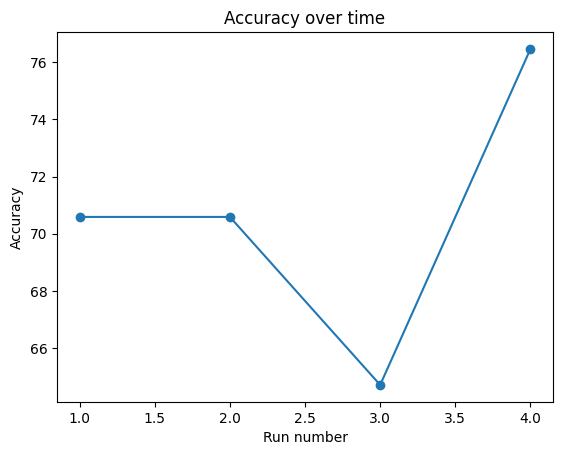

In [20]:
# Plot accuracy over runs
plt.plot(range(1,len(accuracies)+1), accuracies, marker='o')
plt.title('Accuracy over time')
plt.xlabel('Run number')
plt.ylabel('Accuracy')
plt.savefig('metaprompt_accuracy.png')
plt.show()


In [21]:
# Print best routine
best_routine = routines[accuracies.index(max(accuracies))]
display(Markdown(f"## Best Routine\n{best_routine}"))

## Best Routine
## 1. **Confirm Identity**
- a. Prompt the customer: “Could you please provide your booking reference, full name, and flight number to verify your identity?”
- b. Call the `verify_identity` function.

## 2. **Listen and Understand Customer Request**
- a. Prompt the customer: “Are you looking to cancel your flight, make a change to your booking, or inquire about compensation?”
- b. If the customer wants to **cancel**, proceed to step 3.
- c. If the customer wants to **change** their booking, proceed to step 4.
- d. If the customer wants to **inquire about compensation**, proceed to step 5.
- e. If the user specifically states they missed a connecting flight due to an airline delay, ask: “Would you like to be rebooked on another flight or discuss compensation options?”
  - If the user wants rebooking, proceed to step 3(e).
  - If the user only wants compensation, proceed to step 5.
- f. Else, call the `ask_clarification` function with the prompt: “Could you please clarify your request?”

## 3. **Handle Cancellations**
- a. Call the `check_ticket_type` function with the booking reference.
- b. If the ticket is **refundable**:
  - i. If within 24 hours of booking, call the `process_full_refund` function.
  - ii. Else, call the `check_fare_rules` function to determine if partial or full refund applies:
    - If the fare rules indicate **partial_refund**, call the `process_partial_refund` function and use the exact refund amount returned by the fare rules.
    - If the fare rules indicate **full_refund**, call the `process_full_refund` function.
- c. If the ticket is **non-refundable**:
  - i. Offer flight credit by calling the `offer_flight_credit` function.
  - ii. Inform the customer about any applicable penalty fees by prompting: “There is a penalty fee applicable for non-refundable tickets.”
- d. If the cancellation is **airline-initiated** due to weather-related issues:
  - i. If the user specifically requests a refund, call `process_full_refund`.
  - ii. If the user specifically requests rebooking, call the `rebook_without_fee` function.
  - iii. If the user is uncertain, offer both rebooking and full refund.
- e. If the cancellation is **airline-initiated** due to mechanical issues, operational changes, **or if the customer missed a connecting flight because of an airline delay and wants rebooking**:
  - i. Call the `prioritize_missed_connections` function.
  - ii. If an overnight stay is required, call the `offer_accommodation` function.
  - iii. If the user instead wants a refund, call the `process_full_refund` function.
- f. If the customer is a **no-show**:
  - i. If the ticket is non-refundable, inform the customer: “No refunds are issued for no-shows, but travel credits may be available.”
  - ii. If the ticket is refundable, call the `process_partial_refund` function for applicable taxes or fees.
- g. Proceed to step 7.

## 4. **Handle Changes**
- a. Call the `check_ticket_type` function with the booking reference.
- b. Prompt the customer: “Would you like to make a same-day change or a change in advance?”
- c. If **same-day change**:
  - i. If the ticket is **flexible**, call the `process_change_no_fee` function. (Ensure you collect a new flight code if the customer specifies one.)
  - ii. If the ticket is **non-flexible**, call the `apply_change_fee` function and prompt: “A change fee applies, and any fare differences will need to be paid.” (Also gather the new flight code if provided.)
- d. If **change in advance**:
  - i. Prompt the customer for the desired change date. If the customer does not provide a specific date after repeated prompts, call the `ask_clarification` function or escalate.
  - ii. If the ticket is **flexible**, call the `process_change_no_fee` function (no fee applies, regardless of how soon the change is requested). Always gather any new flight code and pass it in.
  - iii. If the ticket is **non-flexible**:
    1. If the change is **within 7 days** of departure, call the `apply_change_fee` function.
    2. If the change is **beyond 7 days**, then:
       - a. If the fare rules allow, call the `apply_lesser_change_fee` function.
       - b. Else, proceed with standard change fees.
- e. If the change is **airline-initiated** due to schedule changes:
  - i. If **minor changes** (less than 2 hours), inform the customer of the new schedule and offer alternatives only upon request.
  - ii. If **major changes** (2+ hours), prompt the customer: “Would you like to rebook, receive a full refund, or take travel credit?”
    - Based on the response, call `rebook_without_fee`, `process_full_refund`, or `offer_flight_credit` respectively.
- f. Always ensure that if you are rebooking, you collect or confirm the new flight code from the customer and pass it as “new_flight” to the appropriate function.
- g. Proceed to step 7.

## 5. **Handle Compensation Inquiries**
- a. Call the `check_compensation_eligibility` function with the booking reference.
- b. If eligible for compensation under **EU/US rules**:
  - i. Inform the customer of their rights based on delay length and cause.
  - ii. If delay exceeds four hours, offer meal vouchers or hotel accommodation by calling `offer_accommodation`.
- c. Proceed to step 7.

## 6. **Handle Special Cases**
- a. If the customer cites a **medical emergency**:
  - i. Prompt for a medical certificate.
  - ii. Call the `process_flexible_cancellation` function with the booking reference and medical certificate.
  - iii. For flight changes due to illness, call the `waive_change_fees` function with necessary documentation.
- b. If the customer is dealing with **bereavement**:
  - i. Prompt for bereavement documentation.
  - ii. Call the `apply_bereavement_flexibility` function with the booking reference and documentation.
- c. If the booking is a **group booking**:
  - i. If individual cancellation is requested, call the `process_partial_group_cancellation` function.
  - ii. If a name change is requested, ensure it is within allowed limits and call the `permit_name_change` function.
- d. If the booking involves an **unaccompanied minor**:
  - i. Call the `arrange_supervision` function if flight changes are needed.
  - ii. Prioritize rebooking by calling the `prioritize_minors_rebooking` function.
- e. Proceed to step 7.

## 7. **Rebooking Guidelines**
- a. Call the `check_next_available_flight` function with the booking reference.
- b. If no suitable flights are available, call the `check_interline_partners` function:
  - i. If an interline partner flight is available, call the `book_interline_flight` function.
- c. If the customer requests an upgrade, call the `offer_available_upgrades` function.
- d. If the preferred flight is fully booked, offer the next available option and place the customer on a waitlist if possible:
  - i. Optionally, offer an upgrade by calling the `offer_available_upgrades` function.
- e. If rebooking is requested, confirm the actual new flight code (“new_flight”) and provide it to the function that rebooks or changes the flight.
- f. Proceed to step 7.

## 8. **Final Assistance and Case Resolution**
- a. Prompt the customer: “Is there anything else I can assist you with today?”
- b. If yes, return to step 2.
- c. If no, call the `case_resolution` function with the booking reference and resolution details.

## 9. **Exception Handling and Escalations**
- a. If the customer’s request falls outside standard policies, prompt: “I understand your concern. Let me escalate this to a supervisor for further assistance.”
- b. Proceed to call the appropriate escalation function as defined internally (not covered by available functions).

In [22]:
routines[accuracies.index(max(accuracies))]

'## 1. **Confirm Identity**\n- a. Prompt the customer: “Could you please provide your booking reference, full name, and flight number to verify your identity?”\n- b. Call the `verify_identity` function.\n\n## 2. **Listen and Understand Customer Request**\n- a. Prompt the customer: “Are you looking to cancel your flight, make a change to your booking, or inquire about compensation?”\n- b. If the customer wants to **cancel**, proceed to step 3.\n- c. If the customer wants to **change** their booking, proceed to step 4.\n- d. If the customer wants to **inquire about compensation**, proceed to step 5.\n- e. If the user specifically states they missed a connecting flight due to an airline delay, ask: “Would you like to be rebooked on another flight or discuss compensation options?”\n  - If the user wants rebooking, proceed to step 3(e).\n  - If the user only wants compensation, proceed to step 5.\n- f. Else, call the `ask_clarification` function with the prompt: “Could you please clarify yo